# Depletion with a Precomputed Flux Spectrum

This example performs a depletion/transmutation/activation simulation using a precomputed multigroup neutron flux spectrum rather than running a full neutron transport simulation.

## Why use a flux spectrum instead of transport?

In a standard OpenMC depletion simulation, neutron transport is run at each timestep to compute reaction rates. This is accurate but computationally expensive and requires a full geometry model.

An alternative approach, used by inventory codes like [FISPACT](https://fispact.ukaea.uk/), [ORIGEN](https://www.ornl.gov/division/rnsd/projects/origen), [ALARA](https://github.com/svalinn/ALARA), and ACAB, is to provide a precomputed multigroup flux spectrum directly. OpenMC collapses this spectrum with cross sections to obtain reaction rates, then solves the Bateman equations as usual.

**Trade-offs:**
- Much faster (no transport needed)
- No geometry model required (just a material + spectrum)
- Less accurate: the multigroup flux is an approximation of the true energy-dependent flux at a specific location
- Well suited for activation screening, parametric studies, and direct comparison with other inventory codes

For verification validation of this approach against experimental data from IAEA CoNDERC and FISPACT, see:
- [openmc_activator GitHub](https://github.com/jbae11/openmc_activator)

## Setup

Import the required packages and configure paths to the nuclear data files.

In [1]:
# remove any old xml files from previous runs
from pathlib import Path
for f in Path('.').glob('*.xml'):
    f.unlink(missing_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import openmc
import openmc.deplete
from openmc.mgxs import GROUP_STRUCTURES

# Path to cross section data (change these if running outside the docker image)
openmc.config['cross_sections'] = Path.home() / 'nuclear_data' / 'cross_sections.xml'

# The chain file describes decay paths between isotopes, including branching
# ratios and half-lives. Download it with:
#   pip install openmc_data
#   download_endf_chain -l endf -r b8.0 -b None
openmc.config['chain_file'] = Path.home() / 'nuclear_data' / 'chain-endf-b8.0.xml'

## Define the material to irradiate

We create a simple mercury (Hg) material. Mercury is interesting because neutron
capture on Hg-196 can produce gold (Au-197) - the ancient dream of alchemy!

Key settings for depletion:
- `volume` must be set so OpenMC can calculate the number of atoms
- `depletable = True` tells OpenMC to update the composition at each timestep

In [2]:
mat = openmc.Material()
mat.add_element('Hg', 1)  # pure mercury
# mat.add_nuclide('Hg198', 1)  # pure Hg-198
mat.set_density('g/cm3', 13.534)
mat.volume = 10  # cm^3 - required for depletion to compute atom counts
mat.depletable = True

## Define the neutron flux spectrum

Instead of running a transport simulation we provide a precomputed multigroup
flux spectrum. This particular spectrum is a DT fusion first-wall spectrum from
the [UKAEA FISPACT reference spectra](https://fispact.ukaea.uk/wiki/Reference_input_spectra)
using the LLNL-616 energy group structure.

The flux values will be normalised internally by OpenMC, so only the spectral
shape matters here. The absolute magnitude is set by the `source_rates` parameter
during the depletion call.

In [3]:
# DT fusion first-wall flux spectrum in LLNL-616 group structure
# Values are flux per energy group (not per unit lethargy)
# Source: UKAEA FISPACT reference input spectra (HCPB first wall)
flux_values = [
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 1.95276813E+06, 2.34205885E+06, 2.48807355E+06, 3.38845478E+06,
    5.68032666E+06, 6.57947511E+06, 5.92509764E+06, 7.69215666E+06, 8.14744853E+06, 1.39975195E+07, 1.02215869E+07,
    1.19745889E+07, 1.96580436E+07, 1.38839476E+07, 2.04283916E+07, 1.84948794E+07, 3.14645059E+07, 2.63941543E+07,
    3.06570629E+07, 3.10991344E+07, 3.47098410E+07, 2.63079712E+07, 4.37276545E+07, 5.44199849E+07, 5.66353631E+07,
    5.78028782E+07, 5.32249135E+07, 6.93508472E+07, 7.45285231E+07, 7.57596297E+07, 8.39456235E+07, 8.53920482E+07,
    9.97620234E+07, 1.05946005E+08, 1.16386703E+08, 1.37301569E+08, 1.35895865E+08, 1.48321841E+08, 1.54736759E+08,
    1.49907720E+08, 1.56010260E+08, 1.96452138E+08, 1.90069015E+08, 2.22189348E+08, 2.03409814E+08, 2.28623791E+08,
    2.56345721E+08, 2.70320761E+08, 2.76567776E+08, 3.06124373E+08, 3.10958433E+08, 3.36548937E+08, 3.38701561E+08,
    3.72301230E+08, 3.79184159E+08, 4.23656279E+08, 4.45092147E+08, 4.79650708E+08, 4.73095777E+08, 5.27893684E+08,
    5.40997968E+08, 5.63653787E+08, 5.50710155E+08, 6.08056179E+08, 6.35439514E+08, 6.47689219E+08, 6.75591325E+08,
    6.57484521E+08, 8.53312459E+08, 1.58528255E+09, 1.71795980E+09, 1.79726493E+09, 1.88281205E+09, 1.91873001E+09,
    2.06632892E+09, 2.10248675E+09, 2.14839525E+09, 2.30958263E+09, 2.36205666E+09, 2.42508463E+09, 2.49307719E+09,
    2.69792506E+09, 2.96642008E+09, 3.05593330E+09, 3.23606979E+09, 3.27445889E+09, 3.52708954E+09, 3.47882146E+09,
    3.66610919E+09, 3.92268919E+09, 4.00780122E+09, 4.04438299E+09, 4.15512121E+09, 4.24819889E+09, 4.19737600E+09,
    4.53618969E+09, 4.63091851E+09, 4.61329143E+09, 4.76370174E+09, 4.60533135E+09, 2.89013276E+09, 5.12601634E+09,
    7.81002382E+09, 7.66019364E+09, 1.05887992E+10, 1.08351878E+10, 1.14200053E+10, 1.17121909E+10, 1.15702259E+10,
    1.35655445E+10, 1.38531560E+10, 1.41027800E+10, 1.45415604E+10, 1.46161408E+10, 1.47766811E+10, 1.56679643E+10,
    1.58720145E+10, 1.67262585E+10, 1.70509649E+10, 1.81623077E+10, 1.64724509E+10, 1.94914788E+10, 2.00396476E+10,
    2.02650622E+10, 2.07776421E+10, 2.08952861E+10, 2.12434768E+10, 2.13580528E+10, 2.18566872E+10, 2.20434450E+10,
    2.24661602E+10, 2.27407745E+10, 2.28049795E+10, 2.31600871E+10, 2.34429571E+10, 2.39380214E+10, 2.40168413E+10,
    2.42473879E+10, 2.48440868E+10, 2.48675152E+10, 2.57808881E+10, 2.63647572E+10, 2.59083497E+10, 2.58469896E+10,
    2.76115385E+10, 2.78632264E+10, 2.81357210E+10, 2.86865115E+10, 2.89376974E+10, 3.04353856E+10, 2.71984177E+10,
    3.01707563E+10, 3.08413663E+10, 3.17114523E+10, 3.04502236E+10, 3.16960565E+10, 3.13242702E+10, 3.26480862E+10,
    3.26666058E+10, 3.22188445E+10, 3.16151170E+10, 2.82595010E+10, 1.98223213E+10, 1.27548103E+10, 2.11219280E+10,
    2.86209677E+10, 3.16264407E+10, 3.31245752E+10, 3.41081217E+10, 3.51065619E+10, 3.56868610E+10, 3.52186835E+10,
    3.64188311E+10, 3.63159693E+10, 3.71484026E+10, 3.69050261E+10, 3.73259563E+10, 3.78976650E+10, 3.72618072E+10,
    3.81156607E+10, 3.79069806E+10, 3.90034296E+10, 3.82680011E+10, 3.89504368E+10, 3.91412109E+10, 3.95631452E+10,
    3.83846410E+10, 3.87080645E+10, 3.33904317E+10, 3.48960968E+10, 4.11735129E+10, 4.63352352E+10, 4.60902411E+10,
    4.65845245E+10, 4.66721579E+10, 4.71060295E+10, 4.72070506E+10, 4.74155075E+10, 4.92591551E+10, 4.93783052E+10,
    4.92994854E+10, 4.82274688E+10, 4.60249763E+10, 4.22981876E+10, 3.72919852E+10, 3.50659527E+10, 3.83095586E+10,
    4.29356631E+10, 4.62452590E+10, 4.79519063E+10, 4.95066594E+10, 4.90466818E+10, 4.97697826E+10, 4.91485954E+10,
    4.76681995E+10, 4.56973134E+10, 3.69773753E+10, 3.51665274E+10, 3.78937045E+10, 4.05635936E+10, 4.25098799E+10,
    4.32332038E+10, 4.30362379E+10, 4.17630718E+10, 3.55770264E+10, 3.89949508E+10, 3.03587970E+10, 3.18867191E+10,
    3.22919746E+10, 2.61430799E+10, 1.92805675E+10, 1.44350727E+10, 1.53777868E+10, 2.02221660E+10, 2.52145902E+10,
    3.17035313E+10, 3.68056228E+10, 3.89047515E+10, 4.11001039E+10, 4.20502928E+10, 4.43140897E+10, 4.53552588E+10,
    4.63313863E+10, 4.80514770E+10, 4.84070866E+10, 5.10973918E+10, 5.16100275E+10, 5.21581962E+10, 5.34400643E+10,
    5.32378549E+10, 5.61428089E+10, 5.83690645E+10, 5.67301923E+10, 6.20216633E+10, 8.04575813E+10, 1.02991238E+11,
    1.85051433E+11, 1.39003474E+11, 2.50307331E+10, 5.35720442E+09, 1.24724424E+10, 2.17532118E+10, 2.94468188E+10,
    3.45794229E+10, 3.76126753E+10, 4.12668360E+10, 4.48148996E+10, 4.64105966E+10, 5.03324546E+10, 5.75987165E+10,
    5.88013742E+10, 5.28206063E+10, 3.44868808E+10, 3.74931905E+10, 4.95917268E+10, 5.37721897E+10, 5.59910821E+10,
    6.19798269E+10, 7.38641607E+10, 8.48431543E+10, 4.32984128E+10, 5.72841066E+10, 1.45159007E+11, 2.37045184E+10,
    4.67252623E+10, 5.08257340E+10, 3.88748524E+10, 4.74179061E+10, 5.62482367E+10, 5.71033732E+10, 6.74113105E+10,
    7.25114496E+10, 8.30464193E+10, 1.33828030E+11, 4.29309217E+10, 3.75896932E+10, 5.39926398E+10, 7.22291932E+10,
    6.89430815E+10, 7.92030464E+10, 7.58020239E+10, 3.36986825E+10, 4.78654443E+10, 7.41910426E+10, 5.86239878E+10,
    6.02455676E+10, 6.29454116E+10, 6.36889843E+10, 1.10938485E+11, 4.49382333E+10, 8.81577148E+10, 1.54973275E+11,
    4.54081401E+10, 8.05998251E+10, 1.17562028E+11, 9.99918448E+10, 4.75234455E+10, 5.06457258E+10, 5.51015282E+10,
    5.95862256E+10, 7.28439098E+10, 6.76946826E+10, 5.71915086E+10, 6.04597701E+10, 7.21165138E+10, 6.91539371E+10,
    7.24902525E+10, 8.70537910E+10, 6.03515532E+10, 7.72149794E+10, 4.99107435E+10, 4.59204410E+10, 4.88990271E+10,
    4.89249099E+10, 4.61880268E+10, 4.80672074E+10, 4.00387417E+10, 3.60197674E+10, 3.59900356E+10, 4.04466190E+10,
    4.34283289E+10, 3.51537534E+10, 3.26966722E+10, 3.25512488E+10, 3.07860306E+10, 2.93076429E+10, 2.74573573E+10,
    2.71033096E+10, 2.88751101E+10, 2.66857263E+10, 2.16069516E+10, 1.91474161E+10, 1.85477607E+10, 1.76073894E+10,
    1.67140423E+10, 1.53231764E+10, 1.29127847E+10, 1.09856316E+10, 1.04950298E+10, 9.77287732E+09, 9.55834013E+09,
    8.95366433E+09, 9.24997779E+09, 8.80444775E+09, 8.15464440E+09, 7.69009273E+09, 7.40962134E+09, 7.29192153E+09,
    7.18236588E+09, 7.00403115E+09, 6.77872805E+09, 6.46227733E+09, 6.17014752E+09, 6.17884950E+09, 6.01618948E+09,
    6.00648343E+09, 5.85525870E+09, 5.81621137E+09, 5.71240125E+09, 5.66269958E+09, 5.62504680E+09, 5.61969173E+09,
    5.74090580E+09, 5.78469459E+09, 6.37542491E+09, 6.66677378E+09, 7.07916937E+09, 7.54439041E+09, 8.23268328E+09,
    8.90970820E+09, 1.14655791E+10, 1.69928960E+10, 2.38352154E+10, 2.95115258E+10, 2.31242751E+10, 2.05195393E+09,
    2.89548782E+06, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
]

## Define the energy group structure

The flux spectrum above uses the LLNL-616 energy group structure (616 energy
groups with 617 bin edges). OpenMC has this built in via the `GROUP_STRUCTURES`
dictionary, so we can reference it by name.

In [4]:
# Get the energy bin edges for the LLNL-616 group structure
# This returns 617 energy values in eV (ascending order)
energy_bin_edges = GROUP_STRUCTURES['LLNL-616']

print(f'Number of energy groups: {len(flux_values)}')
print(f'Number of energy bin edges: {len(energy_bin_edges)}')
print(f'Energy range: {energy_bin_edges[0]:.2e} eV to {energy_bin_edges[-1]:.2e} eV')

Number of energy groups: 616
Number of energy bin edges: 617
Energy range: 1.00e-05 eV to 2.00e+07 eV


## Plot the flux spectrum

Visualise the input spectrum to verify it looks like a DT fusion spectrum.
We expect a peak around 14.1 MeV (the DT fusion neutron energy) with scattered
neutrons at lower energies.

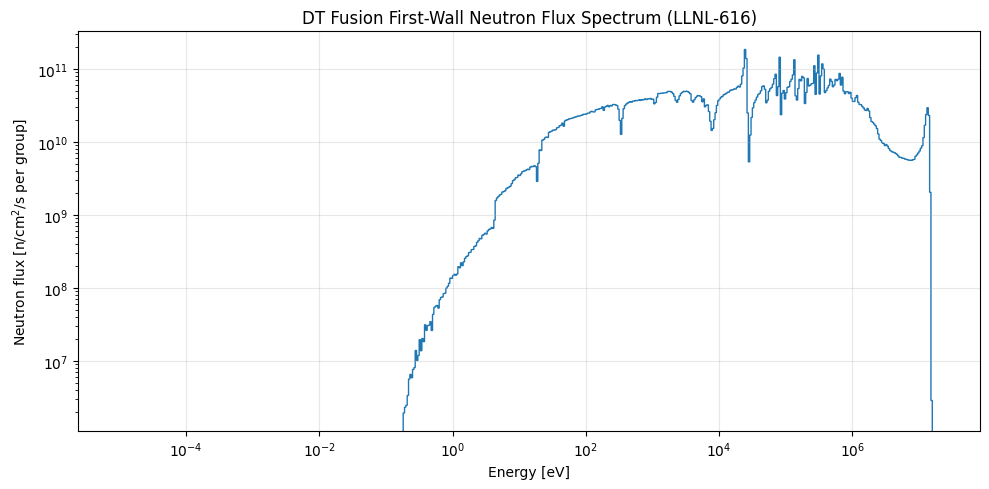

In [5]:
plt.figure(figsize=(10, 5))
plt.stairs(flux_values, energy_bin_edges)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [eV]')
plt.ylabel('Neutron flux [n/cm$^2$/s per group]')
plt.title('DT Fusion First-Wall Neutron Flux Spectrum (LLNL-616)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Define the irradiation schedule

The irradiation schedule is defined by two lists of equal length:
- `timesteps`: duration of each step (in seconds here)
- `source_rates`: neutron source rate during each step (neutrons/second)

A source rate of 0 means no irradiation (cooling/decay only).

We simulate a realistic fusion power plant scenario: 1 year of irradiation
at a first-wall neutron flux of ~4.4e14 n/cm2/s, corresponding to a neutron
wall loading of ~1 MW/m2. This is typical of proposed tokamak power plants
in the 1-2 GW thermal range (e.g. ARC, EU-DEMO, STEP). For context, a
1 GW_th DT fusion plant produces ~3.5e20 neutrons/second, and the wall
loading depends on the first-wall surface area. Compact high-field
tokamaks tend to have higher wall loading (~1-2 MW/m2) while larger
machines like EU-DEMO are lower (~0.5-1 MW/m2).

In [6]:
HOUR = 3600
DAY = 86400
YEAR = 365.25 * DAY

# Neutron flux for ~1 MW/m2 DT first-wall loading
FLUX = 4.4e14  # n/cm2/s

# 1 year irradiation in quarterly steps, then 6 months of cooling
timesteps = [
    # Irradiation: 4 x 3 months
    90*DAY, 90*DAY, 90*DAY, 90*DAY,
    # Cooling: 12 x 15 days (evenly spaced over ~6 months)
    15*DAY, 15*DAY, 15*DAY, 15*DAY,
    15*DAY, 15*DAY, 15*DAY, 15*DAY,
    15*DAY, 15*DAY, 15*DAY, 15*DAY,
]
source_rates = [FLUX] * 4 + [0] * 12

print('Irradiation schedule:')
cumulative = 0
for dt, sr in zip(timesteps, source_rates):
    cumulative += dt
    status = f'{sr:.1e} n/cm2/s' if sr > 0 else 'cooling'
    days = cumulative / DAY
    print(f'  t={days:>8.1f} days  step={dt:>8d}s  {status}')


Irradiation schedule:
  t=    90.0 days  step= 7776000s  4.4e+14 n/cm2/s
  t=   180.0 days  step= 7776000s  4.4e+14 n/cm2/s
  t=   270.0 days  step= 7776000s  4.4e+14 n/cm2/s
  t=   360.0 days  step= 7776000s  4.4e+14 n/cm2/s
  t=   375.0 days  step= 1296000s  cooling
  t=   390.0 days  step= 1296000s  cooling
  t=   405.0 days  step= 1296000s  cooling
  t=   420.0 days  step= 1296000s  cooling
  t=   435.0 days  step= 1296000s  cooling
  t=   450.0 days  step= 1296000s  cooling
  t=   465.0 days  step= 1296000s  cooling
  t=   480.0 days  step= 1296000s  cooling
  t=   495.0 days  step= 1296000s  cooling
  t=   510.0 days  step= 1296000s  cooling
  t=   525.0 days  step= 1296000s  cooling
  t=   540.0 days  step= 1296000s  cooling


## Reduce the depletion chain

The full depletion chain contains thousands of nuclides. Most are irrelevant
for our material. We reduce the chain to only keep nuclides that are reachable
within a few transmutation steps from the initial material composition.

The `level` parameter controls how many reaction steps away from the initial
nuclides to include (e.g. level=3 means up to 3 reactions away). Higher values
include more nuclides (more accurate but slower).

In [7]:
# Load the full chain and reduce it to nuclides reachable from our material
full_chain = openmc.deplete.Chain.from_xml(openmc.config['chain_file'])
print(f'Full chain: {len(full_chain)} nuclides')

reduced_chain = full_chain.reduce(
    initial_isotopes=[nuc.name for nuc in mat.nuclides],
    level=3  # include nuclides up to 3 reactions away
)
print(f'Reduced chain: {len(reduced_chain)} nuclides')

# Get the list of possible reactions from the chain
reactions = reduced_chain.reactions

Full chain: 3820 nuclides
Reduced chain: 109 nuclides


## Run the depletion

The `mat.deplete()` method performs the flux-spectrum-based depletion.
At each timestep it:
1. Collapses the multigroup flux with microscopic cross sections to get one-group reaction rates
2. Builds and solves the Bateman depletion equations to evolve the nuclide inventory

It returns a list of `Material` objects - one for each timestep plus the
original unirradiated material (so len = len(timesteps) + 1).

In [8]:
depleted_materials = mat.deplete(
    multigroup_flux=flux_values,         # the precomputed flux spectrum
    energy_group_structure='LLNL-616',   # name of the energy group structure
    timesteps=timesteps,                  # duration of each step
    source_rates=source_rates,            # neutron source rate at each step
    timestep_units='s',                   # units for timesteps
    chain_file=reduced_chain,             # reduced chain for faster computation
    reactions=reactions,                   # reactions to consider
)

print(f'Number of depleted materials returned: {len(depleted_materials)}')
print(f'  (1 original + {len(timesteps)} timestep results)')

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

          1200K
          2500K
          1200K
          2500K


 Reading W182 from /home/jon/nuclear_data/neutron/W182.h5
 Reading W183 from /home/jon/nuclear_data/neutron/W183.h5
 Reading W184 from /home/jon/nuclear_data/neutron/W184.h5
 Reading W185 from /home/jon/nuclear_data/neutron/W185.h5
 Reading W186 from /home/jon/nuclear_data/neutron/W186.h5
 Reading Re185 from /home/jon/nuclear_data/neutron/Re185.h5
 Reading Re187 from /home/jon/nuclear_data/neutron/Re187.h5
 Reading Os184 from /home/jon/nuclear_data/neutron/Os184.h5
 Reading Os185 from /home/jon/nuclear_data/neutron/Os185.h5
 Reading Os186 from /home/jon/nuclear_data/neutron/Os186.h5
 Reading Os187 from /home/jon/nuclear_data/neutron/Os187.h5
 Reading Os188 from /home/jon/nuclear_data/neutron/Os188.h5
 Reading Os189 from /home/jon/nuclear_data/neutron/Os189.h5
 Reading Os190 from /home/jon/nuclear_data/neutron/Os190.h5
 Reading Os191 from /home/jon/nuclear_data/neutron/Os191.h5
 Reading Os192 from /home/jon/nuclear_data/neutron/Os192.h5
 Reading Ir191 from /home/jon/nuclear_data/neutron

/home/jon/neutronics-workshop/.venv/lib/python3.13/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


[openmc.deplete] t=32400000.0 s, dt=1296000 s, source=0.0
[openmc.deplete] t=33696000.0 s, dt=1296000 s, source=0.0
[openmc.deplete] t=34992000.0 s, dt=1296000 s, source=0.0
[openmc.deplete] t=36288000.0 s, dt=1296000 s, source=0.0
[openmc.deplete] t=37584000.0 s, dt=1296000 s, source=0.0
[openmc.deplete] t=38880000.0 s, dt=1296000 s, source=0.0
[openmc.deplete] t=40176000.0 s, dt=1296000 s, source=0.0
[openmc.deplete] t=41472000.0 s, dt=1296000 s, source=0.0
[openmc.deplete] t=42768000.0 s, dt=1296000 s, source=0.0
[openmc.deplete] t=44064000.0 s, dt=1296000 s, source=0.0
[openmc.deplete] t=45360000.0 s, dt=1296000 s, source=0.0
[openmc.deplete] t=46656000.0 (final operator evaluation)
Number of depleted materials returned: 17
  (1 original + 16 timestep results)


## Extract and plot activity vs time

Each depleted material has methods to query properties like activity,
decay heat, and photon emission spectra.

Here we extract the total activity (in Becquerels) at each timestep and plot
the decay curve. We skip the first entry (index 0) as that is the original
unirradiated material.

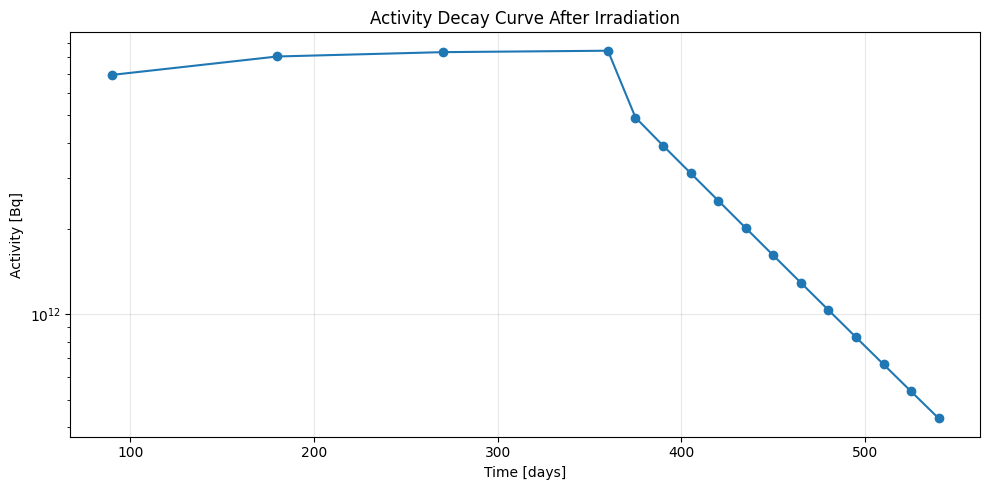

In [9]:
# Get activity at each timestep (skip index 0 which is the original material)
activities = []
for depleted_material in depleted_materials[1:]:
    activity = depleted_material.get_activity(units='Bq')
    activities.append(float(activity))

# Cumulative time at the end of each step, converted to days
times_days = np.cumsum(timesteps) / DAY

plt.figure(figsize=(10, 5))
plt.plot(times_days, activities, 'o-')
plt.xlabel('Time [days]')
plt.ylabel('Activity [Bq]')
plt.title('Activity Decay Curve After Irradiation')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Extract and plot decay heat vs time

Decay heat is the thermal power produced by radioactive decay of the
activated material. This is important for waste handling and cooling
system design.

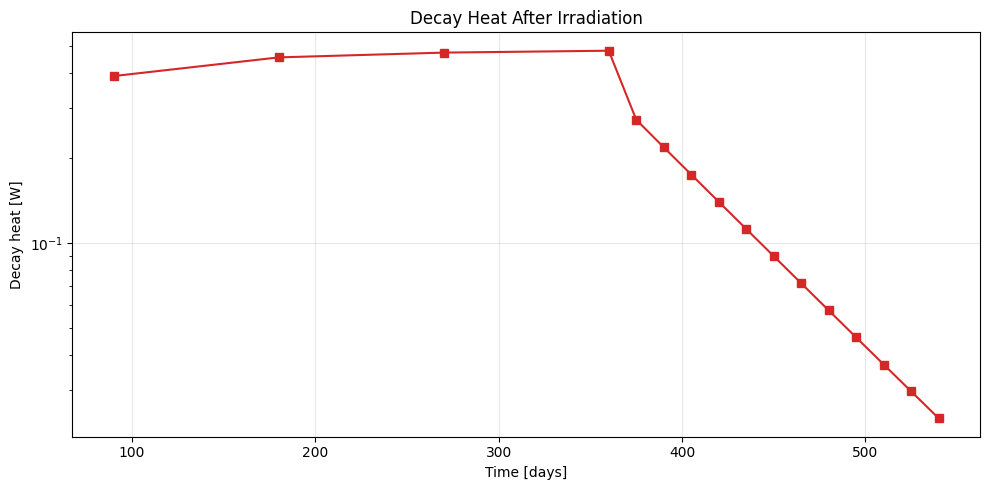

In [10]:
# Get decay heat at each timestep
decay_heats = []
for depleted_material in depleted_materials[1:]:
    heat = depleted_material.get_decay_heat(units='W')
    decay_heats.append(float(heat))

plt.figure(figsize=(10, 5))
plt.plot(times_days, decay_heats, 's-', color='tab:red')
plt.xlabel('Time [days]')
plt.ylabel('Decay heat [W]')
plt.title('Decay Heat After Irradiation')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Extract and plot contact dose rate vs time

The photon contact dose rate estimates the radiation dose a person would
receive from standing next to the activated material. This is critical for
determining when components can be handled, maintained, or recycled.

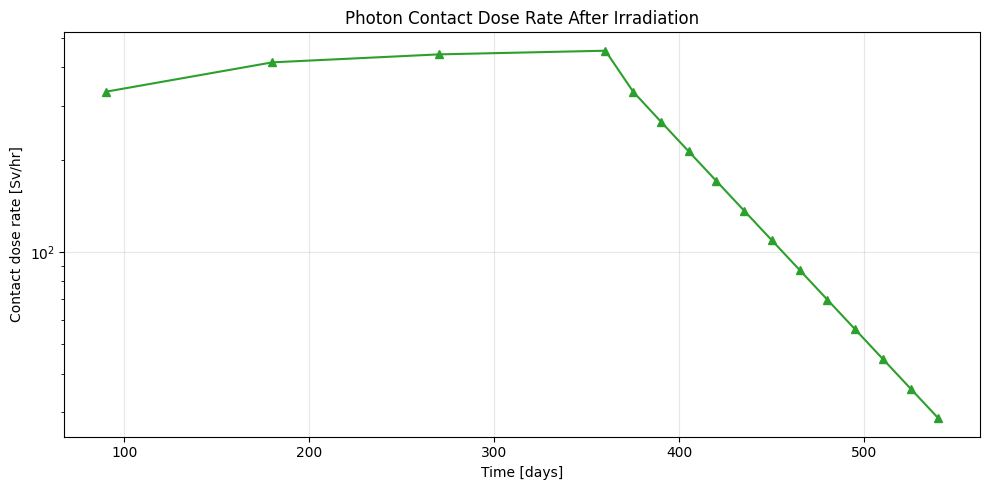

In [11]:
# Get photon contact dose rate at each timestep
dose_rates = []
for depleted_material in depleted_materials[1:]:
    dose = depleted_material.get_photon_contact_dose_rate(dose_quantity='effective')
    dose_rates.append(float(dose))

plt.figure(figsize=(10, 5))
plt.plot(times_days, dose_rates, '^-', color='tab:green')
plt.xlabel('Time [days]')
plt.ylabel('Contact dose rate [Sv/hr]')
plt.title('Photon Contact Dose Rate After Irradiation')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Inspect the nuclide inventory

We can also look at the composition of the material at shutdown (end of
irradiation). Let's check which nuclides were produced and find the most
active ones.

In [12]:
# Get activity broken down by nuclide at shutdown (first post-irradiation step)
shutdown_mat = depleted_materials[1]
activity_by_nuclide = shutdown_mat.get_activity(units='Bq', by_nuclide=True)

# Sort by activity and show the top 10 contributors
sorted_nuclides = sorted(activity_by_nuclide.items(), key=lambda x: x[1], reverse=True)

print('Top 10 most active nuclides at shutdown:')
print(f'{"Nuclide":<12} {"Activity [Bq]":>15}')
print('-' * 28)
for nuc, act in sorted_nuclides[:10]:
    print(f'{nuc:<12} {act:>15.3e}')

Top 10 most active nuclides at shutdown:
Nuclide        Activity [Bq]
----------------------------
Hg203              4.669e+12
Hg205              1.163e+12
Hg197              1.059e+12
Au198              3.039e+10
Hg195              5.197e+09
Au195              1.478e+09
Au199              8.951e+08
Au200              6.881e+08
Tl204              3.684e+08
Au202              3.198e+08


## Check for gold production

Mercury is the element closest to gold on the periodic table. Neutron
capture on Hg-196 followed by electron capture decay can produce stable
Au-197 - the only stable isotope of gold. Let's check if any was produced.

In [13]:
# Check gold and intermediate nuclides at each timestep
# Au-197 is stable gold. Hg-197 (t_1/2 = 64.1 h) is the precursor that
# decays into Au-197 via electron capture. Au-198 (t_1/2 = 2.69 d) is
# unstable gold produced by neutron capture on Au-197.
initial_mass = mat.get_mass()  # total initial mass in grams

print(f'{"Time [days]":>12}  {"Au197 [g]":>12}  {"Hg197 [g]":>12}  {"Au198 [g]":>12}  {"Au197 fraction":>15}')
print('-' * 68)
for i, depleted_material in enumerate(depleted_materials[1:]):
    au197_g = depleted_material.get_mass(nuclide='Au197')
    hg197_g = depleted_material.get_mass(nuclide='Hg197')
    au198_g = depleted_material.get_mass(nuclide='Au198')
    fraction = au197_g / initial_mass
    print(f'{times_days[i]:>12.1f}  {au197_g:>12.6e}  {hg197_g:>12.6e}  {au198_g:>12.6e}  {fraction:>15.6f}')


 Time [days]     Au197 [g]     Hg197 [g]     Au198 [g]   Au197 fraction
--------------------------------------------------------------------
        90.0  2.550320e-03  1.153924e-04  3.355285e-06         0.000019
       180.0  5.113415e-03  1.144464e-04  6.818069e-06         0.000038
       270.0  7.576256e-03  1.135083e-04  1.014543e-05         0.000056
       360.0  9.942099e-03  1.125781e-04  1.334177e-05         0.000073
       375.0  1.005238e-02  2.300679e-06  2.815369e-07         0.000074
       390.0  1.005463e-02  4.701737e-08  5.940970e-09         0.000074
       405.0  1.005468e-02  9.608611e-10  1.253659e-10         0.000074
       420.0  1.005468e-02  1.963645e-11  2.645461e-12         0.000074
       435.0  1.005468e-02  4.012963e-13  5.582430e-14         0.000074
       450.0  1.005468e-02  8.201012e-15  1.178000e-15         0.000074
       465.0  1.005468e-02  1.675983e-16  2.485806e-17         0.000074
       480.0  1.005468e-02  3.425090e-18  5.245529e-19         0.00

Even after a full year of irradiation at reactor-relevant flux, the
conversion fraction of mercury to gold is very small.

With natural mercury (only 10% Hg-198) and a 10 cm3 sample, the gold yeild will be small however it can be increased by enriching the Hg.
The main gold production pathway is the **(n,2n) reaction on Hg-198**, which requires fast neutrons (>9 MeV) that DT fusion provides:

Hg-198 + n -> Hg-197 + 2n -> (electron capture, t_1/2 = 64.1 h) -> Au-197

For the full study see:

> Rutkowski et al., *"Scalable Chrysopoeia via (n,2n) Reactions Driven by
> Deuterium-Tritium Fusion Neutrons"*, 2025.
> [arXiv:2507.13461](https://arxiv.org/abs/2507.13461)

Try rerunning this example with `mat.add_nuclide('Hg198', 1)` instead of `mat.add_element('Hg', 1)` to see how enrichment in Hg-198 increases gold yield via the (n,2n) route.

## Going further

To more accurately simulate gold production a full coupled transport-depletion simulation would be needed.
This accounts for the actual neutron spectrum at the mercury layer, neutron multiplication within the mercury, and self-shielding effects that our simple 0D flux-spectrum approach does not capture.

There are also more advanced features such as [`TransferRates`](https://docs.openmc.org/en/stable/pythonapi/generated/openmc.deplete.TransferRates.html),
which adds continuous removal/feed terms directly into the Bateman depletion equations.

This can be used with the coupled depletion integrators (e.g. `PredictorIntegrator`, `CF4Integrator`) to model isotope extraction during irradiation.

Check out the other tasks in this folder to learn about coupled transport-depletion, isotope build-up tracking, and pulsed irradiation schedules.

## Summary

This notebook demonstrated how to:

1. **Perform depletion with a precomputed flux spectrum** instead of running neutron transport - this is much faster and requires no geometry model
2. **Use a standard multigroup energy structure** (LLNL-616) built into OpenMC
3. **Reduce the depletion chain** to speed up the calculation by excluding irrelevant nuclides
4. **Extract results** including activity, decay heat, and nuclide inventory from the depleted materials

This approach is equivalent to what inventory codes like FISPACT, ORIGEN, ALARA, and ACAB do.
It is an approximation compared to full coupled transport-depletion, but is well suited for:
- Activation screening of candidate materials
- Parametric studies over many materials or irradiation conditions
- Waste classification and disposal assessments
- Benchmarking against other inventory codes
